In [8]:
!pip install streamlit

  Using cached streamlit-1.65.0-py3-none-any.whl.metadata (10 kB)
  Using cached click-8.5.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached protobuf-7.36.2-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached starlette-1.7.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached anyio-4.15.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached idna-3.20-py3-none-any.whl.metadata (7.2 kB)
  Using cached urllib3-2.8.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cac


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.config import (
    RAW_DATA_PATH,
    FEATURED_DATA_PATH,
    MODEL_PATHS,
    PREDS_PATHS,
    FEATURE_COLS,
    TARGET_COL,
    DATE_COL,
)

In [9]:
from src.data_loader import load_featured_data

df = load_featured_data()

print("Dataset shape:", df.shape)
print(
    "Date range:",
    df[DATE_COL].min(),
    "to",
    df[DATE_COL].max()
)

2026-10-06 19:55:36.676 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-10-06 19:55:36.680 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-10-06 19:55:36.681 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-10-06 19:55:36.711 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-06 19:55:36.796 
  command:

    streamlit run d:\1UNI\Inventi\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-10-06 19:55:36.796 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-06 19:55:36.797 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-06 19:55:36.797 No runtime found, using MemoryCa

Dataset shape: (913000, 19)
Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00


In [11]:
train_mask = df[DATE_COL] < "2017-01-01"

train_df = df.loc[train_mask]
val_df = df.loc[~train_mask]

print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))

Training rows: 730500
Validation rows: 182500


In [12]:
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_val = val_df[FEATURE_COLS]
y_val = val_df[TARGET_COL]

print("Features:")
print(FEATURE_COLS)

print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Features:
['store', 'item', 'year', 'month', 'week', 'day', 'dayofweek', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'store_avg_sales', 'item_avg_sales']

Training shape: (730500, 17)
Validation shape: (182500, 17)


In [13]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [14]:
val_preds = xgb_model.predict(X_val)

val_preds = np.clip(
    val_preds,
    0,
    None
)

print("Predictions generated:", len(val_preds))

Predictions generated: 182500


In [15]:
mae = mean_absolute_error(
    y_val,
    val_preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_preds
    )
)

non_zero = y_val != 0

mape = (
    np.mean(
        np.abs(
            (y_val[non_zero] - val_preds[non_zero])
            / y_val[non_zero]
        )
    ) * 100
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.4f}%")

MAE  : 6.0798
RMSE : 7.9126
MAPE : 12.4399%


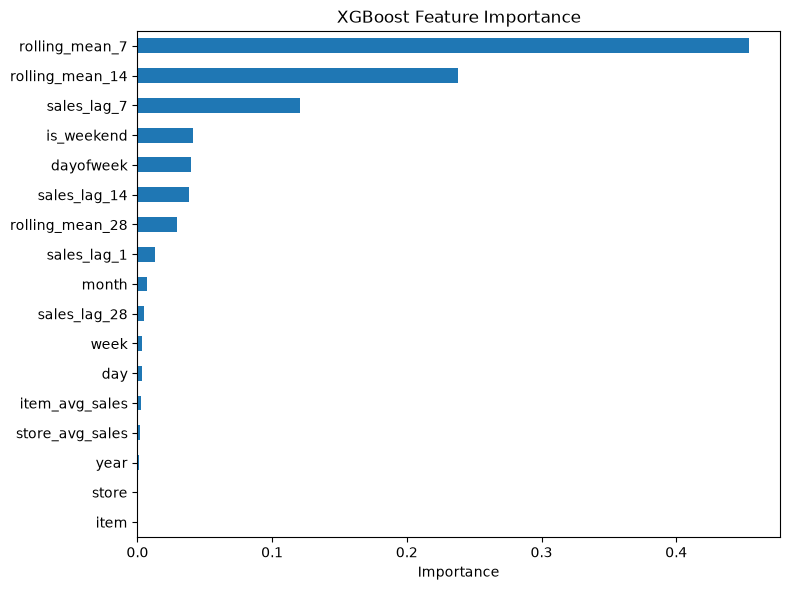

In [16]:
importance = (
    pd.Series(
        xgb_model.feature_importances_,
        index=FEATURE_COLS
    )
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 6))

importance.plot(
    kind="barh"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()

os.makedirs(
    os.path.join(
        os.path.dirname(os.path.dirname(FEATURED_DATA_PATH)),
        "plots",
        "xgboost_plots"
    ),
    exist_ok=True
)

plt.savefig(
    os.path.join(
        os.path.dirname(os.path.dirname(FEATURED_DATA_PATH)),
        "plots",
        "xgboost_plots",
        "xgboost_feature_importance.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

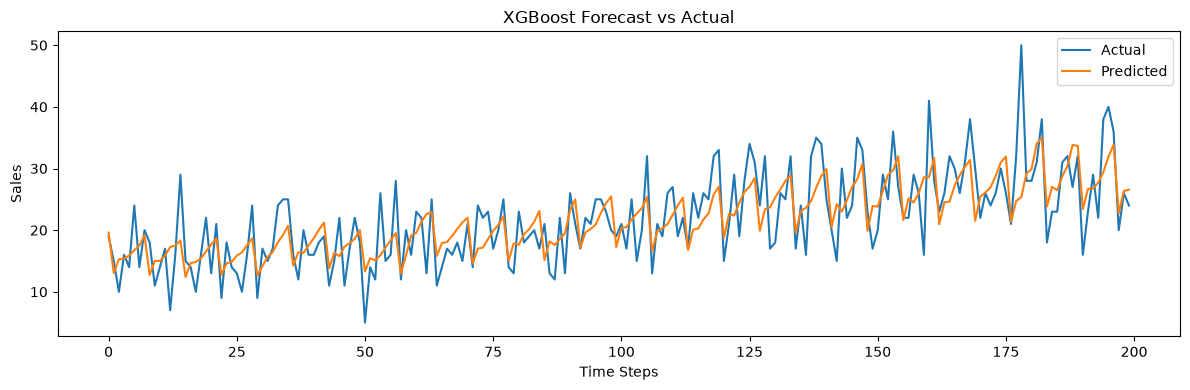

In [17]:
plt.figure(figsize=(12, 4))

plt.plot(
    y_val.values[:200],
    label="Actual"
)

plt.plot(
    val_preds[:200],
    label="Predicted"
)

plt.xlabel("Time Steps")
plt.ylabel("Sales")
plt.title("XGBoost Forecast vs Actual")

plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        os.path.dirname(os.path.dirname(FEATURED_DATA_PATH)),
        "plots",
        "xgboost_plots",
        "xgboost_actual_vs_predicted.png"
    ),
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [18]:
validation_results = val_df[
    [DATE_COL, "store", "item", TARGET_COL]
].copy()

validation_results["prediction"] = val_preds

validation_results["error"] = (
    validation_results[TARGET_COL]
    - validation_results["prediction"]
)

validation_results["absolute_error"] = (
    validation_results["error"]
    .abs()
)

validation_results.head()

,date,store,item,sales,prediction,error,absolute_error
1461,2017-01-01,1,1,19,19.612648,-0.612648,0.612648
1462,2017-01-02,1,1,15,13.040326,1.959674,1.959674
1463,2017-01-03,1,1,10,15.284792,-5.284792,5.284792
1464,2017-01-04,1,1,16,15.387907,0.612093,0.612093
1465,2017-01-05,1,1,14,15.875833,-1.875833,1.875833


In [19]:
os.makedirs(
    os.path.dirname(MODEL_PATHS["XGBoost"]),
    exist_ok=True
)

joblib.dump(
    xgb_model,
    MODEL_PATHS["XGBoost"]
)

joblib.dump(
    val_preds,
    PREDS_PATHS["XGBoost"]
)

joblib.dump(
    y_val.to_numpy(),
    PREDS_PATHS["actual"]
)

# Portable XGBoost format
json_path = os.path.join(
    os.path.dirname(MODEL_PATHS["XGBoost"]),
    "xgb_model.json"
)

xgb_model.save_model(
    json_path
)

print("Saved:")
print("-", MODEL_PATHS["XGBoost"])
print("-", PREDS_PATHS["XGBoost"])
print("-", PREDS_PATHS["actual"])
print("-", json_path)

Saved:
- d:\1UNI\Inventi\models\xgb_model.joblib
- d:\1UNI\Inventi\models\xgb_preds.joblib
- d:\1UNI\Inventi\models\y_val_actual.joblib
- d:\1UNI\Inventi\models\xgb_model.json


In [20]:
print("=" * 50)
print("INVENTI XGBOOST MODEL SUMMARY")
print("=" * 50)

print(f"Training rows   : {len(train_df):,}")
print(f"Validation rows : {len(val_df):,}")
print(f"Features        : {len(FEATURE_COLS)}")
print(f"MAE             : {mae:.4f}")
print(f"RMSE            : {rmse:.4f}")
print(f"MAPE            : {mape:.4f}%")
print("=" * 50)

INVENTI XGBOOST MODEL SUMMARY
Training rows   : 730,500
Validation rows : 182,500
Features        : 17
MAE             : 6.0798
RMSE            : 7.9126
MAPE            : 12.4399%
